# Heart Disease Prediction

## Introduction

This notebook solves the Playground Series S6E2 heart disease classification problem.
The goal is to predict the probability of heart disease, evaluated using ROC-AUC.

***Our strategy:***

Careful preprocessing

Stratified cross-validation

Train **LightGBM**

Blend predictions for a stronger, more stable model

## Import liblary:

In [5]:
!pip install lightgbm --quiet


In [7]:
import numpy as np
import pandas as pd

from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score
from sklearn.impute import SimpleImputer

from lightgbm import LGBMClassifier

import warnings
warnings.filterwarnings("ignore")


## Load Data

In [12]:
import pandas as pd

train = pd.read_csv("train (10).csv")
test = pd.read_csv("test (2).csv")

print("The shape of train:", train.shape)
print("The shape of test:", test.shape)

The shape of train: (630000, 15)
The shape of test: (270000, 14)


In [14]:
train.columns

Index(['id', 'Age', 'Sex', 'Chest pain type', 'BP', 'Cholesterol',
       'FBS over 120', 'EKG results', 'Max HR', 'Exercise angina',
       'ST depression', 'Slope of ST', 'Number of vessels fluro', 'Thallium',
       'Heart Disease'],
      dtype='str')

## Missing values:

In [17]:
train.isnull().mean().sort_values(ascending=False).head(10)


id                 0.0
Age                0.0
Sex                0.0
Chest pain type    0.0
BP                 0.0
Cholesterol        0.0
FBS over 120       0.0
EKG results        0.0
Max HR             0.0
Exercise angina    0.0
dtype: float64

## Exploratory Data Analysis

### Traget Distribution

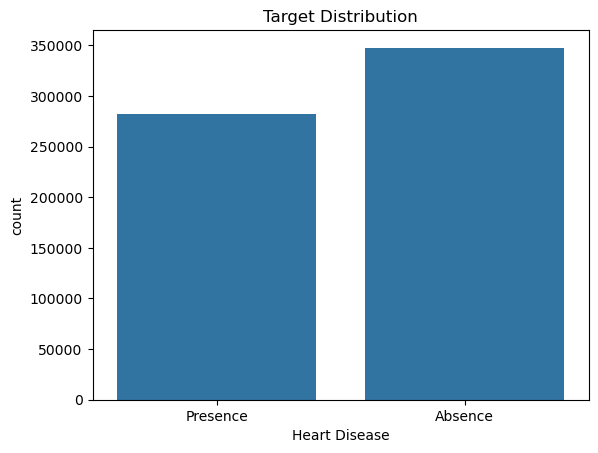

Heart Disease
Absence     0.55166
Presence    0.44834
Name: proportion, dtype: float64

In [21]:
import matplotlib.pyplot as plt
import seaborn as sns
sns.countplot(x ="Heart Disease", data = train)
plt.title("Target Distribution")
plt.show()
train["Heart Disease"].value_counts(normalize=True)

### Convert Target to Numeric

In [24]:
train["Heart Disease Num"] = train["Heart Disease"].map({"Presence": 1, "Absence": 0})

**Presence == 1**

**Absence == 0**

### Numerical Feature Distributions vs Target

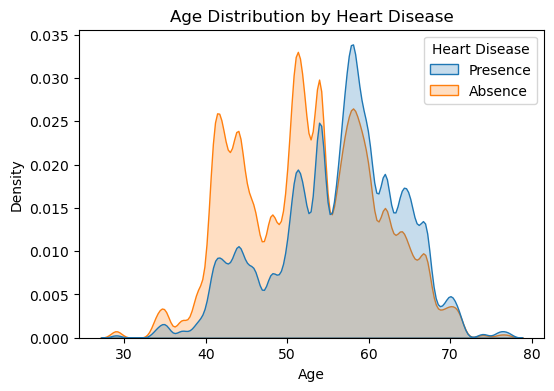

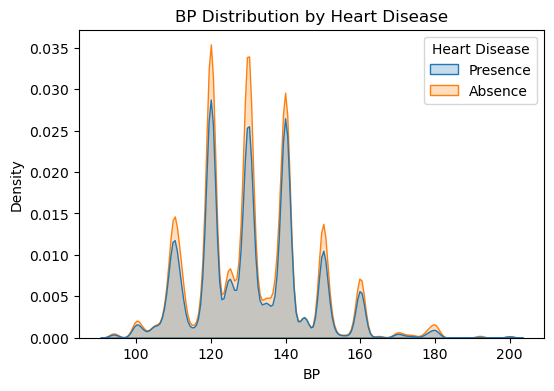

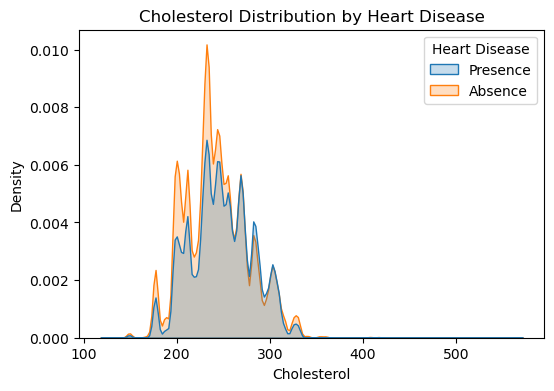

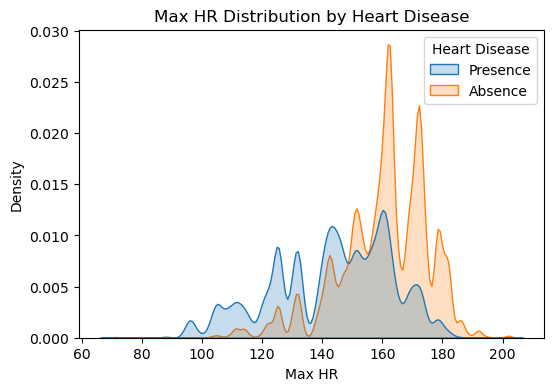

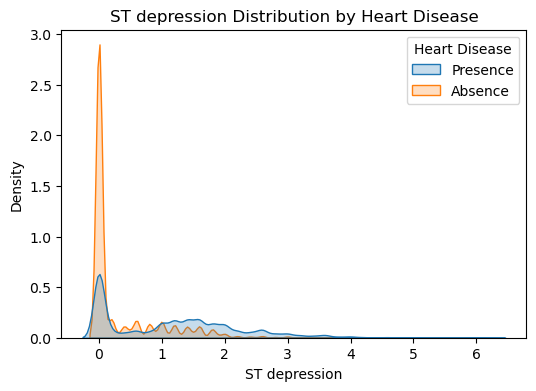

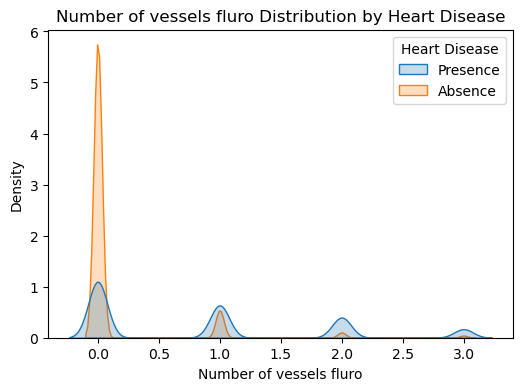

In [28]:
num_cols = ['Age','BP','Cholesterol','Max HR','ST depression','Number of vessels fluro']

for col in num_cols:
    plt.figure(figsize=(6,4))
    sns.kdeplot(data=train, x=col, hue="Heart Disease", fill=True)
    plt.title(f"{col} Distribution by Heart Disease")
    plt.show()

### 🧠What to Look For
Shift in distribution between healthy vs diseased

Nonlinear thresholds

Wider variance in risk group

### Categorical Features vs Disease Rate

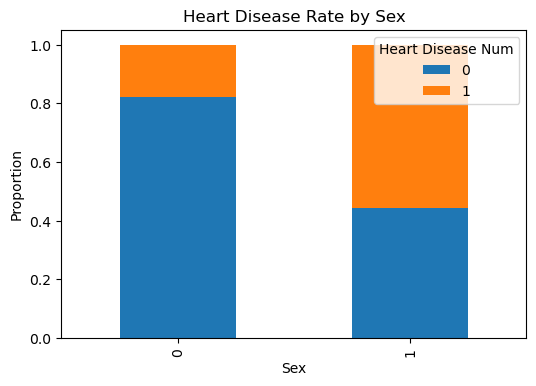

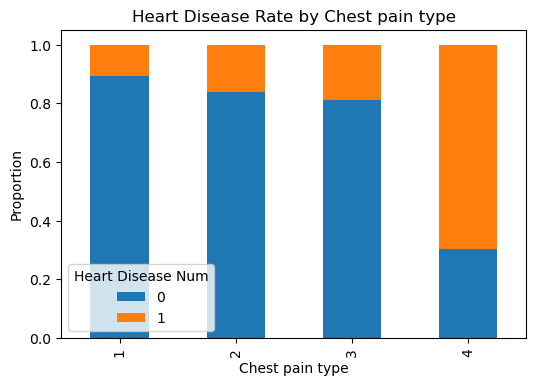

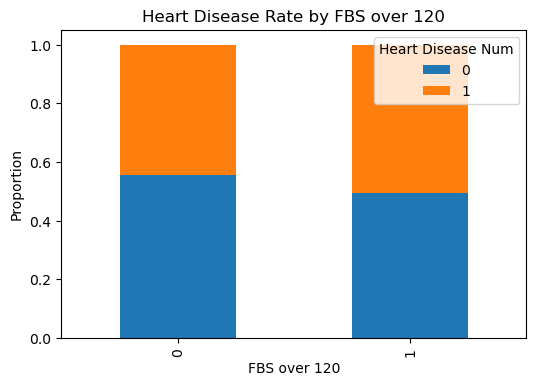

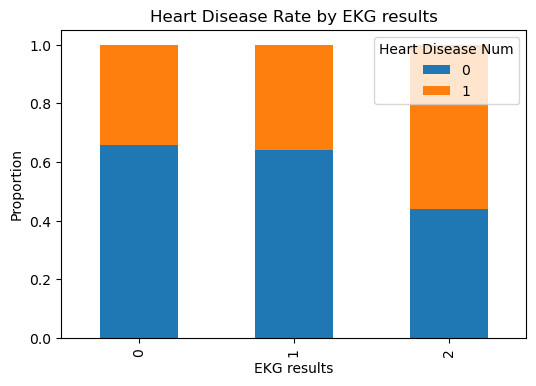

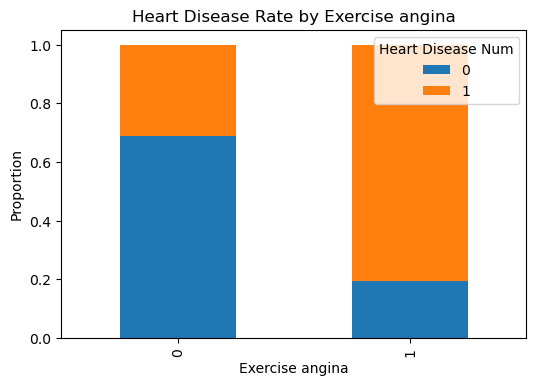

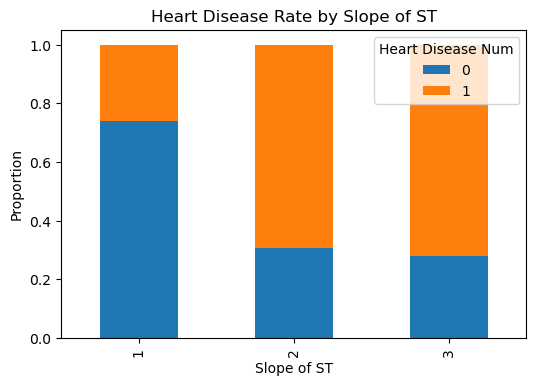

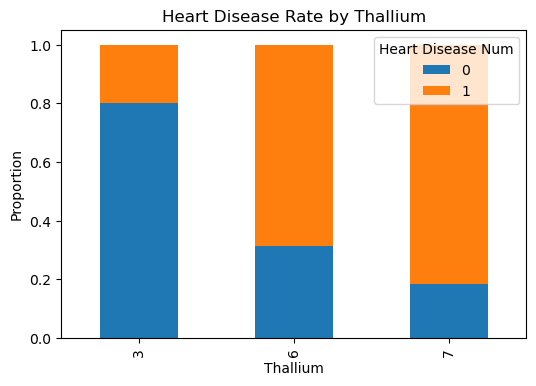

In [32]:
cat_cols = ['Sex','Chest pain type','FBS over 120','EKG results',
            'Exercise angina','Slope of ST','Thallium']

for col in cat_cols:
    ct = pd.crosstab(train[col], train["Heart Disease Num"], normalize="index")
    ct.plot(kind="bar", stacked=True, figsize=(6,4))
    plt.title(f"Heart Disease Rate by {col}")
    plt.ylabel("Proportion")
    plt.show()

#### 🧠 Insights¶
Some categories show much higher disease prevalence

Strong categorical predictors are ideal for tree models

### Correlation Analysis


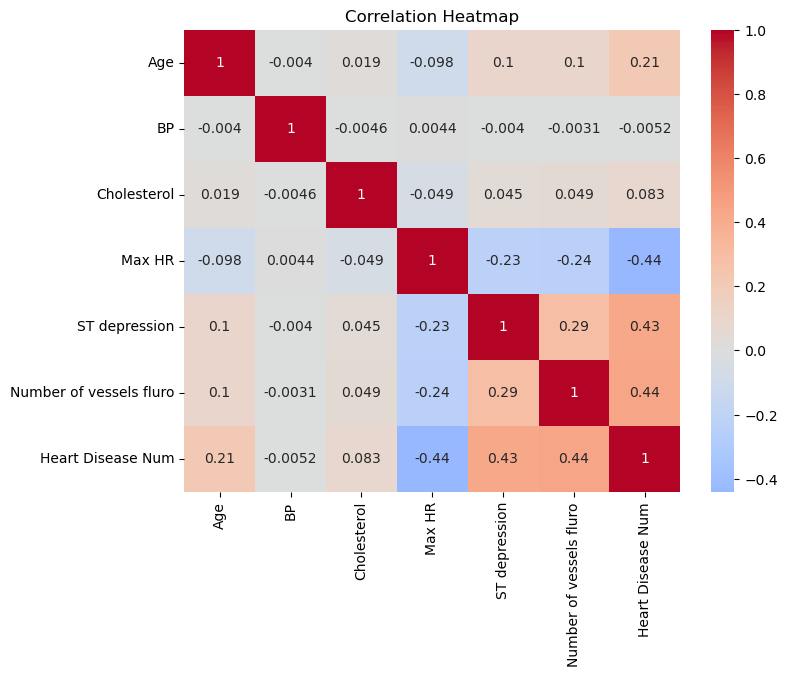

In [36]:
corr = train[num_cols + ["Heart Disease Num"]].corr()

plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, cmap="coolwarm", center=0)
plt.title("Correlation Heatmap")
plt.show()

#### 🧠 Insights
Identify highly correlated features

Detect redundant variables

See which features most relate to heart disease

## Preprocessing

In [40]:
target = "Heart Disease"

drop_cols = ["id", "Heart Disease", "Heart Disease Num"]

train_features = [col for col in train.columns if col not in drop_cols]

# Keep only columns that also exist in test
features = [col for col in train_features if col in test.columns]

print("Using features:", features)
print("Dropped (not in test):", set(train_features) - set(features))

X = train[features].copy()
y = train[target]
X_test = test[features].copy()


Using features: ['Age', 'Sex', 'Chest pain type', 'BP', 'Cholesterol', 'FBS over 120', 'EKG results', 'Max HR', 'Exercise angina', 'ST depression', 'Slope of ST', 'Number of vessels fluro', 'Thallium']
Dropped (not in test): set()


In [42]:
def create_age_group(df):
    return pd.cut(df["Age"],
                  bins=[0, 40, 50, 60, 70, 100],
                  labels=[0,1,2,3,4])

X["Age Group"] = create_age_group(X).astype("category")
X_test["Age Group"] = create_age_group(X_test).astype("category")


## Categorical Features

In [45]:
cat_cols = [
    "Sex",
    "Chest pain type",
    "FBS over 120",
    "EKG results",
    "Exercise angina",
    "Slope of ST",
    "Number of vessels fluro",
    "Thallium",
    "Age Group"
]


**These are categorical even if encoded as numbers:**

### Convert to category dtype:

In [49]:
for col in cat_cols:
    X[col] = X[col].astype("category")
    X_test[col] = X_test[col].astype("category")


## Feature engineering

In [52]:
X["age_chol_ratio"] = X["Age"] / (X["Cholesterol"] + 1)
X_test["age_chol_ratio"] = X_test["Age"] / (X_test["Cholesterol"] + 1)

X["bp_hr_product"] = X["BP"] * X["Max HR"]
X_test["bp_hr_product"] = X_test["BP"] * X_test["Max HR"]


**Medical risk** often depends on interactions rather than single values. These engineered features help tree models capture nonlinear effects.

## Model 1 — LightGBM

In [56]:
folds = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

lgb_oof = np.zeros(len(X))
lgb_test = np.zeros(len(X_test))

for fold, (train_idx, val_idx) in enumerate(folds.split(X, y)):
    print(f"LightGBM Fold {fold+1}")
    
    X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
    y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]
    
    model = LGBMClassifier(
        n_estimators=1500,
        learning_rate=0.02,
        num_leaves=63,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42
    )
    
    model.fit(X_train, y_train,
              eval_set=[(X_val, y_val)],
              eval_metric="auc",
              )
    
    lgb_oof[val_idx] = model.predict_proba(X_val)[:, 1]
    lgb_test += model.predict_proba(X_test)[:, 1] / folds.n_splits

print("LightGBM CV AUC:", roc_auc_score(y, lgb_oof))


LightGBM Fold 1
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 225963, number of negative: 278037
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.054181 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 941
[LightGBM] [Info] Number of data points in the train set: 504000, number of used features: 16
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.448339 -> initscore=-0.207383
[LightGBM] [Info] Start training from score -0.207383
LightGBM Fold 2
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 225963, number of negative: 278037
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.115893 

LightGBM Fold 2


[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 225963, number of negative: 278037
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.014222 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 936
[LightGBM] [Info] Number of data points in the train set: 504000, number of used features: 16
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.448339 -> initscore=-0.207383
[LightGBM] [Info] Start training from score -0.207383


LightGBM Fold 3


[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 225963, number of negative: 278037
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.008842 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 933
[LightGBM] [Info] Number of data points in the train set: 504000, number of used features: 16
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.448339 -> initscore=-0.207383
[LightGBM] [Info] Start training from score -0.207383


LightGBM Fold 4


[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 225963, number of negative: 278037
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.008464 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 935
[LightGBM] [Info] Number of data points in the train set: 504000, number of used features: 16
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.448339 -> initscore=-0.207383
[LightGBM] [Info] Start training from score -0.207383


LightGBM Fold 5


[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 225964, number of negative: 278036
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.009165 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 936
[LightGBM] [Info] Number of data points in the train set: 504000, number of used features: 16
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.448341 -> initscore=-0.207375
[LightGBM] [Info] Start training from score -0.207375


LightGBM CV AUC: 0.955072504113791


## submission

In [59]:
submission = pd.DataFrame({
    "id": test["id"],
    "Heart Disease": lgb_test
})

submission.to_csv("submission.csv", index=False)
submission.head()


,id,Heart Disease
0,630000,0.958958
1,630001,0.009665
2,630002,0.985459
3,630003,0.006478
4,630004,0.169276


#### Check Prediction Range

In [62]:
lgb_test.min(), lgb_test.max()


(0.0002203967433121867, 0.999865787332239)

#### Predictions

In [65]:
np.std(lgb_test)


0.408371682393499

#### Compare Model CV vs Ensemble CV


In [68]:
print("LightGBM CV:", roc_auc_score(y, lgb_oof))



LightGBM CV: 0.955072504113791


In [70]:
submission.tail()

,id,Heart Disease
269995,899995,0.145657
269996,899996,0.640181
269997,899997,0.045000
269998,899998,0.198535
269999,899999,0.027270


In [78]:
import joblib

joblib.dump(model, "lightgbm_model.pkl")

['lightgbm_model.pkl']

In [82]:
joblib.dump(X_train.columns.tolist(), "feature_names.pkl")

['feature_names.pkl']

In [84]:
joblib.dump(cat_cols, "categorical_features.pkl")

['categorical_features.pkl']

In [86]:
joblib.dump(X.columns.tolist(), "feature_names.pkl")

['feature_names.pkl']

In [88]:
print("Features:")
print(X.columns.tolist())

print("\nCategorical columns:")
print(cat_cols)

print("\nCategorical values:")
for col in cat_cols:
    print(col, "=>", X[col].cat.categories.tolist())

Features:
['Age', 'Sex', 'Chest pain type', 'BP', 'Cholesterol', 'FBS over 120', 'EKG results', 'Max HR', 'Exercise angina', 'ST depression', 'Slope of ST', 'Number of vessels fluro', 'Thallium', 'Age Group', 'age_chol_ratio', 'bp_hr_product']

Categorical columns:
['Sex', 'Chest pain type', 'FBS over 120', 'EKG results', 'Exercise angina', 'Slope of ST', 'Number of vessels fluro', 'Thallium', 'Age Group']

Categorical values:
Sex => [0, 1]
Chest pain type => [1, 2, 3, 4]
FBS over 120 => [0, 1]
EKG results => [0, 1, 2]
Exercise angina => [0, 1]
Slope of ST => [1, 2, 3]
Number of vessels fluro => [0, 1, 2, 3]
Thallium => [3, 6, 7]
Age Group => [0, 1, 2, 3, 4]


In [90]:
print(X.dtypes)

Age                           int64
Sex                        category
Chest pain type            category
BP                            int64
Cholesterol                   int64
FBS over 120               category
EKG results                category
Max HR                        int64
Exercise angina            category
ST depression               float64
Slope of ST                category
Number of vessels fluro    category
Thallium                   category
Age Group                  category
age_chol_ratio              float64
bp_hr_product                 int64
dtype: object
